# Seminar 14: CLIP Multimodal Retrieval and Zero-Shot Classification

Today is an interactive CLIP lab.

Goals:
- compute image and text embeddings in one shared space,
- inspect similarity matrices,
- retrieve images from text queries,
- retrieve text descriptions from images,
- perform zero-shot classification with prompt templates,
- inspect failures and improve prompts.

Expected rhythm: 5 medium board tasks, about 90 minutes total.


## 0. Setup

If you run this in Colab and packages are missing, uncomment the install line first.


In [1]:
# If needed in Colab, uncomment:
# %pip install transformers torchvision scikit-learn -q

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.datasets import Caltech101
from transformers import CLIPModel, AutoProcessor

pd.set_option('display.max_colwidth', 120)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)


device: cuda


### Provided CLIP and Caltech101 Setup

This is setup, not a board exercise.

We use Caltech101 because it has higher-resolution object images and diverse visual categories. This makes CLIP retrieval more meaningful than tiny low-resolution image datasets.


In [2]:
CFG = {
    'model_name': 'openai/clip-vit-base-patch32',
    'gallery_size': 220,
    'query_size': 24,
    'eval_size': 260,
    'seed': 42,
    'top_k': 6,
}

model = CLIPModel.from_pretrained(CFG['model_name']).to(device)
processor = AutoProcessor.from_pretrained(CFG['model_name'])
model.eval()

raw_dataset = Caltech101(root='./data', download=True)
raw_class_names = raw_dataset.categories

background_id = None
for class_id, class_name in enumerate(raw_class_names):
    if 'background' in class_name.lower():
        background_id = class_id

valid_indices = []
valid_class_ids = []
for index in range(len(raw_dataset)):
    _, label = raw_dataset[index]
    if label != background_id:
        valid_indices.append(index)
        if label not in valid_class_ids:
            valid_class_ids.append(label)

valid_class_ids = sorted(valid_class_ids)
label_id_map = {}
class_names = []
for new_label_id, old_label_id in enumerate(valid_class_ids):
    label_id_map[old_label_id] = new_label_id
    class_names.append(raw_class_names[old_label_id])

rng = torch.Generator().manual_seed(CFG['seed'])
shuffled_positions = torch.randperm(len(valid_indices), generator=rng).tolist()
shuffled_indices = []
for position in shuffled_positions:
    shuffled_indices.append(valid_indices[position])

gallery_indices = shuffled_indices[:CFG['gallery_size']]
query_indices = shuffled_indices[CFG['gallery_size']:CFG['gallery_size'] + CFG['query_size']]
eval_indices = shuffled_indices[CFG['gallery_size'] + CFG['query_size']:CFG['gallery_size'] + CFG['query_size'] + CFG['eval_size']]


def format_class_name(class_name):
    name = class_name.replace('_', ' ')
    name = name.replace('-', ' ')
    return name.lower()


def collect_images_and_labels(dataset, indices):
    images = []
    labels = []
    for index in indices:
        image, old_label = dataset[index]
        images.append(image.convert('RGB'))
        labels.append(label_id_map[old_label])
    return images, labels


gallery_images, gallery_labels = collect_images_and_labels(raw_dataset, gallery_indices)
query_images, query_labels = collect_images_and_labels(raw_dataset, query_indices)
eval_images, eval_labels = collect_images_and_labels(raw_dataset, eval_indices)

print('number of classes:', len(class_names))
print('gallery images:', len(gallery_images))
print('query images:', len(query_images))
print('eval images:', len(eval_images))
print('example classes:', class_names[:12])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

100%|██████████| 137M/137M [00:12<00:00, 11.4MB/s]


number of classes: 101
gallery images: 220
query images: 24
eval images: 260
example classes: ['Faces', 'Faces_easy', 'Leopards', 'Motorbikes', 'accordion', 'airplanes', 'anchor', 'ant', 'barrel', 'bass', 'beaver', 'binocular']


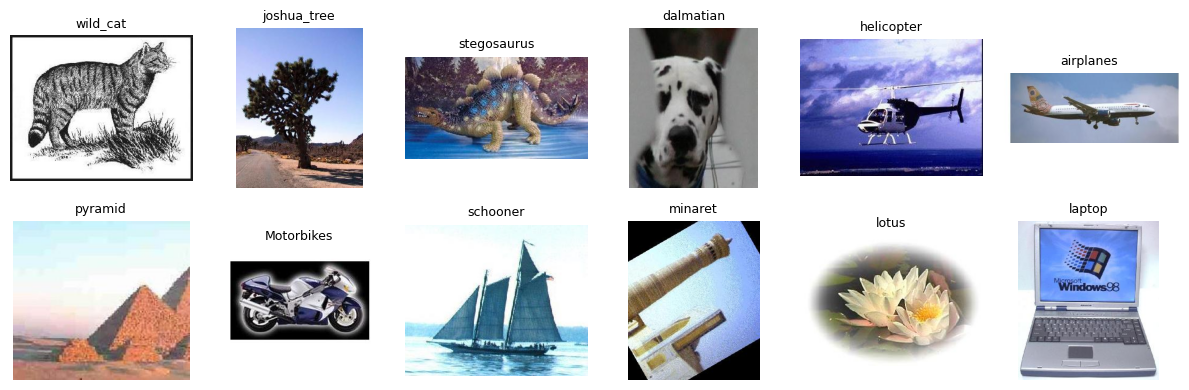

In [3]:
def clip_image_features(model, inputs):
    # Use the explicit image tower and projection layer.
    # This avoids version differences in model.get_image_features(...).
    vision_outputs = model.vision_model(pixel_values=inputs['pixel_values'])
    features = model.visual_projection(vision_outputs.pooler_output)
    return features


def clip_text_features(model, inputs):
    # Use the explicit text tower and projection layer.
    # This avoids version differences in model.get_text_features(...).
    text_outputs = model.text_model(
        input_ids=inputs['input_ids'],
        attention_mask=inputs['attention_mask'],
    )
    features = model.text_projection(text_outputs.pooler_output)
    return features

def show_images(images, labels=None, titles=None, scores=None, ncols=6, figsize=(12, 5)):
    count = len(images)
    nrows = (count + ncols - 1) // ncols
    plt.figure(figsize=figsize)

    for i in range(count):
        plt.subplot(nrows, ncols, i + 1)
        plt.imshow(images[i])
        plt.axis('off')

        title_parts = []
        if labels is not None:
            title_parts.append(str(labels[i]))
        if titles is not None:
            title_parts.append(str(titles[i]))
        if scores is not None:
            title_parts.append(f'{float(scores[i]):.3f}')

        if len(title_parts) > 0:
            plt.title('\n'.join(title_parts), fontsize=9)

    plt.tight_layout()
    plt.show()


preview_labels = []
for label in gallery_labels[:12]:
    preview_labels.append(class_names[label])

show_images(gallery_images[:12], labels=preview_labels, ncols=6, figsize=(12, 4))


## 1. Exercise 1: Embeddings and Similarity Matrix

CLIP maps images and texts into the same embedding space.

Task:
- implement image/text encoding helpers,
- normalize embeddings,
- compute a similarity matrix,
- inspect whether matching image-text pairs receive high scores.

Expected implementation:
1. `encode_images` should call `processor(images=..., return_tensors='pt')`.
2. Move processor outputs to `device`.
3. Use the provided `clip_image_features(model, inputs)` helper to get image features.
4. `encode_texts` should call `processor(text=..., return_tensors='pt', padding=True, truncation=True)`.
5. Use the provided `clip_text_features(model, inputs)` helper to get text features.
6. Normalize embeddings row-wise with `F.normalize`.
7. `compute_similarity(a, b)` should return `a @ b.T`.

Function contracts:
- `encode_images(images, model, processor)` returns a tensor `[num_images, embedding_dim]`,
- `encode_texts(texts, model, processor)` returns a tensor `[num_texts, embedding_dim]`,
- embeddings should be tensors and should be L2-normalized,
- `clip_image_features` and `clip_text_features` are provided helpers that call the CLIP image/text towers and projection layers,
- `compute_similarity(image_emb, text_emb)` returns `[num_images, num_texts]`.


In [9]:
def encode_images(images, model, processor):
    # Expected steps:
    # 1. inputs = processor(images=images, return_tensors='pt')
    inputs = processor(images=images, return_tensors='pt')
    # 2. move inputs to device
    inputs = inputs.to(device)
    # 3. features = clip_image_features(model, inputs)
    with torch.no_grad() :
      features = clip_image_features(model, inputs)
    # 4. return F.normalize(features, dim=1)
    return F.normalize(features, dim=1)


def encode_texts(texts, model, processor):
    # Expected steps:
    # 1. inputs = processor(text=texts, return_tensors='pt', padding=True, truncation=True)
    inputs = processor(text=texts, return_tensors='pt', padding=True, truncation=True)
    # 2. move inputs to device
    inputs = inputs.to(device)
    # 3. features = clip_text_features(model, inputs)
    with torch.no_grad() :
      features = clip_text_features(model, inputs)
    # 4. return F.normalize(features, dim=1)
    return F.normalize(features, dim=1)


def compute_similarity(left_emb, right_emb):
    # Dot product of normalized embeddings equals cosine similarity.
    return left_emb @ right_emb.T


demo_images = []
demo_labels = []
seen_labels = []
for image, label in zip(gallery_images, gallery_labels):
    if label not in seen_labels:
        demo_images.append(image)
        demo_labels.append(label)
        seen_labels.append(label)
    if len(demo_images) == 6:
        break

demo_texts = []
for label in demo_labels:
    demo_texts.append('a photo of a ' + format_class_name(class_names[label]))

demo_image_emb = encode_images(demo_images, model, processor)
demo_text_emb = encode_texts(demo_texts, model, processor)
demo_similarity = compute_similarity(demo_image_emb, demo_text_emb)

gallery_emb = encode_images(gallery_images, model, processor)
query_emb = encode_images(query_images, model, processor)

demo_similarity


tensor([[0.2904, 0.1816, 0.2200, 0.2134, 0.1690, 0.1699],
        [0.2154, 0.3403, 0.2076, 0.1815, 0.2096, 0.1921],
        [0.2063, 0.2220, 0.3123, 0.2076, 0.1910, 0.1767],
        [0.1957, 0.1536, 0.1764, 0.2938, 0.1866, 0.1872],
        [0.2007, 0.1623, 0.1274, 0.1863, 0.2881, 0.2319],
        [0.1754, 0.1322, 0.1336, 0.1683, 0.1796, 0.2654]], device='cuda:0')

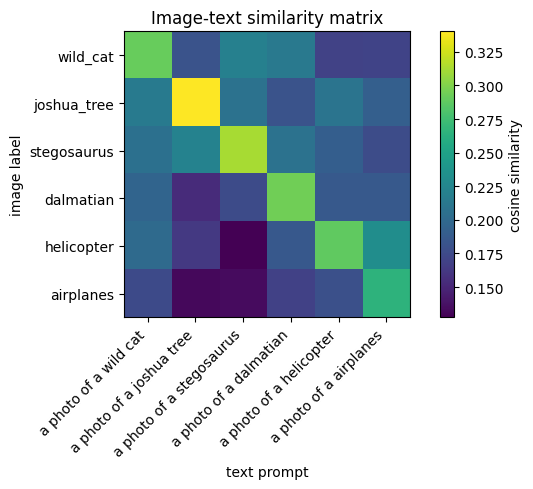

In [7]:
plt.figure(figsize=(7, 5))
plt.imshow(demo_similarity.detach().cpu().numpy(), cmap='viridis')
plt.colorbar(label='cosine similarity')
plt.xticks(range(len(demo_texts)), demo_texts, rotation=45, ha='right')
y_labels = []
for label in demo_labels:
    y_labels.append(class_names[label])
plt.yticks(range(len(demo_images)), y_labels)
plt.xlabel('text prompt')
plt.ylabel('image label')
plt.title('Image-text similarity matrix')
plt.tight_layout()
plt.show()


### Checks (Exercise 1)

In [8]:
assert demo_image_emb is not None
assert demo_text_emb is not None
assert demo_similarity is not None
assert isinstance(demo_image_emb, torch.Tensor), 'encode_images must return a tensor from model.get_image_features(...), not a model output object.'
assert isinstance(demo_text_emb, torch.Tensor), 'encode_texts must return a tensor from model.get_text_features(...), not a model output object.'
assert isinstance(gallery_emb, torch.Tensor), 'gallery_emb must be a tensor. Check encode_images.'
assert demo_image_emb.shape[0] == len(demo_images)
assert demo_text_emb.shape[0] == len(demo_texts)
assert demo_similarity.shape == (len(demo_images), len(demo_texts))
assert gallery_emb.shape[0] == len(gallery_images)
assert query_emb.shape[0] == len(query_images)

image_norms = gallery_emb.norm(dim=1)
assert torch.allclose(image_norms, torch.ones_like(image_norms), atol=1e-4)

print('Exercise 1 passed.')


Exercise 1 passed.


## 2. Exercise 2: Text-to-Image Search

Text-to-image retrieval asks: which gallery images best match this text query?

Task:
- implement `retrieve_images_by_text`,
- test several natural-language queries,
- visualize top results with labels and similarity scores.

Expected implementation:
1. Encode the query text with `encode_texts`.
2. Compute similarity between query embedding and `gallery_emb`.
3. Sort scores from largest to smallest with `torch.topk`.
4. Collect top images, labels, and scores.
5. Display the results.

Function contract:
- `retrieve_images_by_text(query, gallery_emb, gallery_images, gallery_labels, top_k)` returns `images`, `label_names`, `scores`.


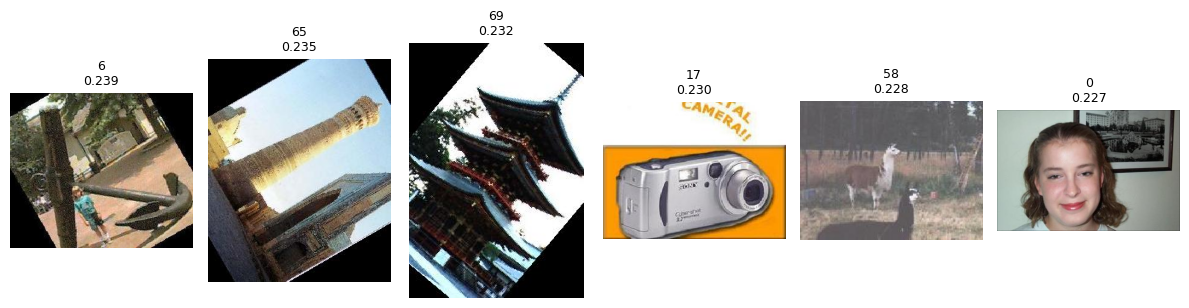

In [18]:
text_queries = [
    'a photo of a motorbike',
    'a spotted wild animal',
    'a musical instrument',
    'a flying object',
]


def retrieve_images_by_text(query, gallery_emb, gallery_images, gallery_labels, top_k=6):
    images = []
    labels = []
    scores = []

    encoded_text = encode_texts([query], model, processor)
    encoded_image = encode_images(gallery_images, model, processor)

    scores = compute_similarity(encoded_text, encoded_image) # [1, images]
    scores, indices = torch.topk(scores, k=top_k, dim=1)

    images = [gallery_images[i] for i in indices[0]]
    labels = [gallery_labels[i] for i in indices[0]]

    return images, labels, scores[0]


query = "a photo of a photo"
retrieved_images, retrieved_labels, retrieved_scores = retrieve_images_by_text(
    query,
    gallery_emb,
    gallery_images,
    gallery_labels,
    top_k=CFG['top_k'],
)

show_images(retrieved_images, labels=retrieved_labels, scores=retrieved_scores, ncols=CFG['top_k'], figsize=(12, 3))


### Checks (Exercise 2)

In [ ]:
assert len(retrieved_images) == CFG['top_k']
assert len(retrieved_labels) == CFG['top_k']
assert len(retrieved_scores) == CFG['top_k']
for score in retrieved_scores:
    assert isinstance(score, float)

print('Exercise 2 passed.')


## 3. Exercise 3: Image-to-Text Search

Image-to-text retrieval asks: which text descriptions best match this image?

Task:
- create candidate text prompts,
- implement `retrieve_texts_by_image`,
- choose a query image and rank candidate descriptions.

Expected implementation:
1. Encode candidate texts once.
2. Encode one query image.
3. Compute image-to-text similarity.
4. Return top text prompts and scores.
5. Compare whether the best prompts are class-specific or more general.

Function contract:
- `retrieve_texts_by_image(image, candidate_texts, model, processor, top_k)` returns `texts`, `scores`.


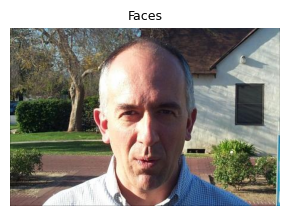

,text,score
0,a human face,0.214435
1,an animal,0.197109
2,a photo of a camera,0.196199
3,a spotted animal,0.195292
4,a vehicle,0.185638


In [26]:
candidate_texts = [
    'a photo of an airplane',
    'a photo of a motorbike',
    'a photo of a camera',
    'a photo of a chair',
    'a photo of a sunflower',
    'a photo of a watch',
    'a photo of a guitar',
    'a spotted animal',
    'a human face',
    'a kitchen object',
    'an animal',
    'a vehicle',
    'a household object',
    'something with wheels',
]


def retrieve_texts_by_image(image, candidate_texts, model, processor, top_k=5):
    texts = []
    scores = []
    encode_image = encode_images([image], model, processor)
    encode_candidate = encode_texts(candidate_texts, model, processor)
    similarity = compute_similarity(encode_image, encode_candidate)
    scores, indices = torch.topk(similarity, k=top_k, dim=1)
    for i in indices[0]:
        texts.append(candidate_texts[i])

    return texts, scores[0].detach().cpu().float()


query_image = query_images[0]
query_label = class_names[query_labels[0]]
retrieved_texts, text_scores = retrieve_texts_by_image(query_image, candidate_texts, model, processor, top_k=5)

show_images([query_image], labels=[query_label], ncols=1, figsize=(3, 3))
pd.DataFrame({'text': retrieved_texts, 'score': text_scores})


### Checks (Exercise 3)

In [27]:
assert len(retrieved_texts) == 5
assert len(text_scores) == 5
for text in retrieved_texts:
    assert isinstance(text, str)
for score in text_scores:
    assert isinstance(score, float)

print('Exercise 3 passed.')


AssertionError: 

## 4. Exercise 4: Zero-Shot Classification and Prompt Templates

CLIP can classify images by comparing them to text prompts for each class.

Task:
- implement zero-shot classification by similarity,
- compare several prompt templates,
- compute accuracy for each template.

Expected implementation:
1. Build one prompt per class from a template.
2. Encode all class prompts.
3. Encode evaluation images.
4. Compute image-text similarities.
5. Choose the class with maximum similarity.
6. Compare predictions with true labels.

Function contracts:
- `build_class_prompts(class_names, template)` returns one prompt per class,
- `zero_shot_predict(images, class_prompts, model, processor)` returns predicted label ids and similarity scores,
- `evaluate_prompt_template(template)` returns an accuracy value and predictions.


In [50]:
from sklearn.metrics import accuracy_score


prompt_templates = [
    '{}',
    'a photo of a {}',
    'a photo of the object {}',
]


def build_class_prompts(class_names, template):
    prompts = []
    for class_name in class_names:
      prompts.append(template.format(class_name))

    return prompts


def zero_shot_predict(images, class_prompts, model, processor):
    encoded_texts = encode_texts(texts=class_prompts, model=model, processor=processor)
    encoded_images = encode_images(images=images, model=model, processor=processor)
    similarity_scores = compute_similarity(encoded_texts, encoded_images)
    predictions = similarity_scores.argmax(0)
    return predictions, similarity_scores


def evaluate_prompt_template(template, eval_images, eval_labels):
    prompts = build_class_prompts(template=template, class_names=class_names)
    predictions, scores = zero_shot_predict(images=eval_images, class_prompts=prompts, model=model, processor=processor)
    accuracy = accuracy_score(y_true=eval_labels, y_pred=predictions.cpu())
    return accuracy, predictions, scores


prompt_results = []
for template in prompt_templates:
    accuracy, predictions, scores = evaluate_prompt_template(template, eval_images, eval_labels)
    prompt_results.append({'template': template, 'accuracy': accuracy})

prompt_results_df = pd.DataFrame(prompt_results)
prompt_results_df


torch.Size([260])
torch.Size([260])
torch.Size([260])


,template,accuracy
0,{},0.850000
1,a photo of a {},0.888462
2,a photo of the object {},0.834615


### Checks (Exercise 4)

In [51]:
assert isinstance(prompt_results_df, pd.DataFrame)
for column in ['template', 'accuracy']:
    assert column in prompt_results_df.columns
assert len(prompt_results_df) == len(prompt_templates)
assert prompt_results_df['accuracy'].between(0, 1).all()

sorted_prompt_results = prompt_results_df.sort_values('accuracy', ascending=False).reset_index(drop=True)
best_template = sorted_prompt_results.loc[0, 'template']
best_accuracy, best_predictions, best_scores = evaluate_prompt_template(best_template, eval_images=eval_images, eval_labels=eval_labels)

print('best template:', best_template)
print('best accuracy:', best_accuracy)
print('Exercise 4 passed.')


torch.Size([260])
best template: a photo of a {}
best accuracy: 0.8884615384615384
Exercise 4 passed.


## 5. Exercise 5: Failure Gallery and Prompt Fixing

A good CLIP lab should inspect mistakes, not only accuracy.

Task:
- find misclassified examples from the best prompt template,
- show the image, true label, predicted label, and top-3 class scores,
- suggest prompt changes for confusing classes.

Expected implementation:
1. Use `best_predictions` and `eval_labels` to find mistakes.
2. For each mistake, sort class scores descending.
3. Store true label, predicted label, and top-3 labels/scores.
4. Visualize several mistakes.
5. Write concrete notes about possible prompt improvements.

Function contract:
- `build_failure_table(predictions, scores, true_labels, class_names, max_rows)` returns a DataFrame with mistake details.


In [ ]:
def build_failure_table(predictions, scores, true_labels, class_names, max_rows=8):
    rows = []
    return pd.DataFrame(rows)


best_accuracy, best_predictions, best_scores = evaluate_prompt_template(best_template, eval_images=eval_images, eval_labels=eval_labels)

failure_table = build_failure_table(best_predictions, best_scores, eval_labels, class_names, max_rows=8)

failure_table


In [ ]:
if len(failure_table) > 0:
    mistake_images = []
    mistake_titles = []
    for row_index in range(len(failure_table)):
        image_index = int(failure_table.loc[row_index, 'image_index'])
        mistake_images.append(eval_images[image_index])
        title = 'true: ' + failure_table.loc[row_index, 'true_label'] + '\npred: ' + failure_table.loc[row_index, 'predicted_label']
        mistake_titles.append(title)

    show_images(mistake_images, titles=mistake_titles, ncols=4, figsize=(12, 6))
else:
    print('No mistakes found in the inspected subset.')


### Checks (Exercise 5)

In [ ]:
assert isinstance(failure_table, pd.DataFrame)
for column in ['image_index', 'true_label', 'predicted_label', 'top_3_labels', 'top_3_scores']:
    assert column in failure_table.columns


print('Exercise 5 passed.')


## 6. Wrap-Up Questions

1. What does it mean that CLIP has a joint image-text embedding space?
2. Why can the same similarity matrix support text-to-image and image-to-text retrieval?
3. Why is zero-shot classification possible without a Caltech101 classifier head?
4. Which prompt template worked best, and why might that happen?
5. Which errors were understandable from the image quality or prompt wording?
6. What are the limits of using CLIP as a classifier?


## Optional Extension

Try one of these:
- upload your own image and rank custom text prompts,
- write natural-language queries such as `something with wheels` or `a pet`,
- create class-specific prompt templates for confusing classes,
- compare top retrieved images and bottom retrieved images for one query.
